# 9. Recurrent Neural Networks

Up until now, we have focused primarily on fixed-length data. When introducing linear and logistic regression in Section 3 and Section 4 and multilayer perceptrons in Section 5, we were happy to assume that each feature vector $\mathbf{x}_i$ consisted of a fixed number of components $x_1, x_2, \cdots, x_d$ , where each numerical feature $x_j$ corresponded to a particular attribute. These datasets are sometimes called *tabular*, because they can be arranged in tables, where each example $i$ gets its own row, and each attribute gets its own column. **Crucially, with tabular data, we seldom assume any particular structure over the columns**.

Subsequently, in Section 7, we moved on to image data, where inputs consist of the raw pixel values at each coordinate in an image. Image data hardly fitted the bill of a prototypical tabular dataset. There, we needed to **call upon convolutional neural networks (CNNs) to handle the hierarchical structure and invariances**. However, our data were still of fixed length. Every Fashion-MNIST image is represented as a $28 \times 28$  grid of pixel values. Moreover, our goal was to develop a model that looked at just one image and then outputted a single prediction. But what should we do when faced with a sequence of images, as in a video, or when tasked with producing a sequentially structured prediction, as in the case of image captioning?

A great many learning tasks require dealing with sequential data. Image captioning, speech synthesis, and music generation all require that models produce outputs consisting of sequences. In other domains, such as time series prediction, video analysis, and musical information retrieval, a model must learn from inputs that are sequences. These demands often arise simultaneously: tasks such as translating passages of text from one natural language to another, engaging in dialogue, or controlling a robot, demand that models both ingest and output sequentially structured data.

**Recurrent neural networks (RNNs) are deep learning models that capture the dynamics of sequences via *recurrent* connections, which can be thought of as cycles in the network of nodes**. This might seem counterintuitive at first. After all, it is the feedforward nature of neural networks that makes the order of computation unambiguous. However, recurrent edges are defined in a precise way that ensures that no such ambiguity can arise. Recurrent neural networks are *unrolled* across time steps (or sequence steps), with the *same* underlying parameters applied at each step. While the standard connections are applied *synchronously* to propagate each layer’s activations to the subsequent layer *at the same time step*, the recurrent connections are *dynamic*, passing information across adjacent time steps. As the unfolded view in Fig. 9.1 reveals, RNNs can be thought of as feedforward neural networks where each layer’s parameters (both conventional and recurrent) are shared across time steps.

<p align="center">
  <img src="https://d2l.ai/_images/unfolded-rnn.svg"/>
  <br />
  <em>Fig. 9.1</em> On the left recurrent connections are depicted via cyclic edges. On the right, we unfold the RNN over time steps. Here, recurrent edges span adjacent time steps, while conventional connections are computed synchronously.
</p>

Like neural networks more broadly, RNNs have a long discipline-spanning history, originating as models of the brain popularized by cognitive scientists and subsequently adopted as practical modeling tools employed by the machine learning community. As we do for deep learning more broadly, in this book we adopt the machine learning perspective, focusing on RNNs as practical tools that rose to popularity in the 2010s owing to breakthrough results on such diverse tasks as handwriting recognition (Graves et al., 2008), machine translation (Sutskever et al., 2014), and recognizing medical diagnoses (Lipton et al., 2016). We point the reader interested in more background material to a publicly available comprehensive review (Lipton et al., 2015). We also note that sequentiality is not unique to RNNs. For example, the CNNs that we already introduced can be adapted to handle data of varying length, e.g., images of varying resolution. Moreover, RNNs have recently ceded considerable market share to Transformer models, which will be covered in Section 11. However, RNNs rose to prominence as the default models for handling complex sequential structure in deep learning, and remain staple models for sequential modeling to this day. The stories of RNNs and of sequence modeling are inextricably linked, and this is as much a chapter about the ABCs of sequence modeling problems as it is a chapter about RNNs.

One key insight paved the way for a revolution in sequence modeling. While the inputs and targets for many fundamental tasks in machine learning cannot easily be represented as fixed-length vectors, they can often nevertheless **be represented as varying-length sequences of fixed-length vectors**.

While sequence models have popped up in numerous application areas, basic research in the area has been driven predominantly by advances on core tasks in natural language processing. Thus, throughout this chapter, we will focus our exposition and examples on text data. If you get the hang of these examples, then applying the models to other data modalities should be relatively straightforward. In the next few sections, we introduce basic notation for sequences and some evaluation measures for assessing the quality of sequentially structured model outputs. After that, we discuss basic concepts of a language model and use this discussion to motivate our first RNN models. Finally, we describe the method for calculating gradients when backpropagating through RNNs and explore some challenges that are often encountered when training such networks, motivating the modern RNN architectures that will follow in Section 10.

## 9.1. Working with Sequences

Up until now, we have focused on models whose inputs consisted of a single feature vector $\mathbf{x} \in \mathbb{R}^d$. The main change of perspective when developing models capable of processing sequences is that we now focus on inputs that consist of an ordered list of feature vectors $\mathbf{x}_1, \dots, \mathbf{x}_T$, where each feature vector $\mathbf{x}_t$ is indexed by a time step $t \in \mathbb{Z}^+$ lying in $\mathbb{R}^d$.

Some datasets consist of a single massive sequence. Consider, for example, the extremely long streams of sensor readings that might be available to climate scientists. In such cases, we might create training datasets by randomly sampling subsequences of some predetermined length. More often, our data arrives as a collection of sequences. Consider the following examples: (i) a collection of documents, each represented as its own sequence of words, and each having its own length $T_i$; (ii) sequence representation of patient stays in the hospital, where each stay consists of a number of events and the sequence length depends roughly on the length of the stay.

Previously, when dealing with individual inputs, we assumed that they were sampled independently from the same underlying distribution $P(X)$. While we still assume that entire sequences (e.g., entire documents or patient trajectories) are sampled independently, we cannot assume that the data arriving at each time step are independent of each other. For example, the words that likely to appear later in a document depend heavily on words occurring earlier in the document. The medicine a patient is likely to receive on the 10th day of a hospital visit depends heavily on what transpired in the previous nine days.

This should come as no surprise. If we did not believe that the elements in a sequence were related, we would not have bothered to model them as a sequence in the first place. Consider the usefulness of the auto-fill features that are popular on search tools and modern email clients. They are useful precisely because it is often possible to predict (imperfectly, but better than random guessing) what the likely continuations of a sequence might be, given some initial prefix. For most sequence models, we do not require independence, or even stationarity, of our sequences. Instead, we require only that the sequences themselves are sampled from some fixed underlying distribution over entire sequences.

This flexible approach allows for such phenomena as (i) documents looking significantly different at the beginning than at the end; or (ii) patient status evolving either towards recovery or towards death over the course of a hospital stay; or (iii) customer taste evolving in predictable ways over the course of continued interaction with a recommender system.

We sometimes wish to predict a fixed target $y$ given sequentially structured input (e.g., sentiment classification based on a movie review). At other times, we wish to predict a sequentially structured target ($y_1, \ldots, y_T$) given a fixed input (e.g., image captioning). Still other times, our goal is to predict sequentially structured targets based on sequentially structured inputs (e.g., machine translation or video captioning). Such sequence-to-sequence tasks take two forms: (i) *aligned*: where the input at each time step aligns with a corresponding target (e.g., part of speech tagging); (ii) *unaligned*: where the input and target do not necessarily exhibit a step-for-step correspondence (e.g., machine translation).

Before we worry about handling targets of any kind, we can tackle the most straightforward problem: unsupervised density modeling (also called **sequence modeling**). Here, given a collection of sequences, our goal is to **estimate the probability mass function** that tells us how likely we are to see any given sequence, i.e., $p(\mathbf{x}_1, \ldots, \mathbf{x}_T)$.

In [1]:
import torch
from d2l import torch as d2l

### 9.1.1. Autoregressive Models

Before introducing specialized neural networks designed to handle sequentially structured data, let's take a look at some actual sequence data and build up some basic intuitions and statistical tools. In particular, we will focus on stock price data from the FTSE 100 index (Fig. 9.1.1). At each *time step* $t \in \mathbb{Z}^+$, we observe the price, $x_t$, of the index at that time.

<p align="center">
  <img src="https://d2l.ai/_images/ftse100.png"/>
  <br />
  <em>Fig. 1.1.1</em> FTSE 100 index over about 30 years.
</p>

Now suppose that a trader would like to make short-term trades, strategically getting into or out of the index, depending on whether they believe that it will rise or decline in the subsequent time step. Absent any other features (news, financial reporting data, etc.), the only available signal for predicting the subsequent value is the history of prices to date. The trader is thus interested in knowing the probability distribution

$$P(x_t \mid x_{t-1}, \ldots, x_1) \tag{9.1.1}$$

One simple strategy for estimating the conditional expectation

$$\mathbb{E}[(x_t \mid x_{t-1}, \ldots, x_1)], \tag{9.1.2}$$

would be to apply a linear regression model (recall Section 3.1). Such models that regress the value of a signal on the previous values of that same signal are naturally called **autoregressive models**. There is just one major problem: the number of inputs, $x_{t-1}, \ldots, x_1$ varies, depending on $t$. In other words, the number of inputs increases with the amount of data that we encounter. Thus if we want to treat our historical data as a training set, we are left with the problem that each example has a different number of features. Much of what follows in this chapter will revolve around techniques for overcoming these challenges when engaging in such *autoregressive* modeling problems where the object of interest is $P(x_t \mid x_{t-1}, \ldots, x_1)$ or some statistic(s) of this distribution.

A few strategies recur frequently. First of all, we might believe that although long sequences $x_{t-1}, \ldots, x_1$ are available, it may not be necessary to look back so far in the history when predicting the near future. In this case we might content ourselves to condition on some window of length $\tau$ and only use $x_{t-1}, \ldots, x_{t-\tau}$ observations. The immediate benefit is that now the number of arguments is always the same, at least for $t > \tau$. This allows us to train any linear model or deep network that requires fixed-length vectors as inputs. Second, we might develop models that maintain some summary $h_t$ of the past observations (see Fig. 9.1.2) and at the same time update $h_t$ in addition to the prediction $\hat{x}_t$. This leads to models that estimate not only $x_t$ with $\hat{x}_t = P(x_t \mid h_{t})$ but also updates of the form $h_t = g(h_{t-1}, x_{t-1})$. Since $h_t$ is never observed, these models are also called ***latent autoregressive models***.

<p align="center">
  <img src="https://d2l.ai/_images/sequence-model.svg"/>
  <br />
  <em>Fig. 1.1.1</em> A latent autoregressive model.
</p>

To construct training data from historical data, one typically creates examples by sampling windows randomly. In general, we do not expect time to stand still. However, we often assume that while the specific values of $x_t$ might change, the *dynamics* according to which each subsequent observation is generated given the previous observations do not. Statisticians call dynamics that do not change **stationary**.

### 9.1.2. Sequence Models

Sometimes, especially when working with language, we wish to estimate the joint probability of an entire sequence. This is a common task when working with sequences composed of discrete *tokens*, such as words. Generally, these estimated functions are called *sequence models* and for natural language data, they are called **language models**. The field of sequence modeling has been driven so much by natural language processing, that we often describe sequence models as "language models", even when dealing with non-language data. Language models prove useful for all sorts of reasons. Sometimes we want to evaluate the likelihood of sentences. For example, we might wish to compare the naturalness of two candidate outputs generated by a machine translation system or by a speech recognition system. But language modeling gives us not only the capacity to *evaluate* likelihood, but the ability to *sample* sequences, and even to optimize for the most likely sequences.

While language modeling might not, at first glance, look like an autoregressive problem, we can reduce language modeling to autoregressive prediction by decomposing the joint density  of a sequence $p(x_1, \ldots, x_T)$ into the product of conditional densities in a left-to-right fashion by applying the chain rule of probability:

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}, \ldots, x_1). \tag{9.1.3}$$

Note that if we are working with discrete signals such as words, then the autoregressive model must be a *probabilistic classifier*, outputting a full probability distribution over the vocabulary for whatever word will come next, given the leftwards context.

#### 9.1.2.1. Markov Models

Now suppose that we wish to employ the strategy mentioned above, where we condition only on the $\tau$ previous time steps, i.e., $x_{t-1}, \ldots, x_{t-\tau}$, rather than the entire sequence history $x_{t-1}, \ldots, x_1$. Whenever we can throw away the history beyond the previous $\tau$ steps without any loss in predictive power, we say that the sequence satisfies a **Markov condition**, i.e., *that the future is conditionally independent of the past, given the recent history*. When $\tau = 1$, we say that the data is characterized by a *first-order Markov model*, and when $\tau = k$, we say that the data is characterized by a $k^{\textrm{th}}$-order Markov model. For when the first-order Markov condition holds ($\tau = 1$) the factorization of our joint probability becomes a product of probabilities of each word given the previous *word*:

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}). \tag{9.1.5} $$

We often find it useful to work with models that proceed as though a Markov condition were satisfied, even when we know that this is only *approximately* true. With real text documents we continue to gain information as we include more and more leftwards context. But these gains diminish rapidly. Thus, sometimes we compromise, obviating computational and statistical difficulties by training models whose validity depends on a $k^{\textrm{th}}$-order Markov condition. Even today's massive RNN- and Transformer-based language models seldom incorporate more than thousands of words of context.

With discrete data, a true Markov model simply counts the number of times that each word has occurred in each context, producing the relative frequency estimate of $P(x_t \mid x_{t-1})$. Whenever the data assumes only discrete values (as in language), the most likely sequence of words can be computed efficiently using dynamic programming.

#### 9.1.2.2. The Order of Decoding

You may be wondering why we represented the factorization of a text sequence $P(x_1, \ldots, x_T)$ as a left-to-right chain of conditional probabilities. Why not right-to-left or some other, seemingly random order? In principle, there is nothing wrong with unfolding $P(x_1, \ldots, x_T)$ in reverse order. The result is a valid factorization:

$$P(x_1, \ldots, x_T) = P(x_T) \prod_{t=T-1}^1 P(x_t \mid x_{t+1}, \ldots, x_T). \tag{9.1.5}$$

However, there are many reasons why factorizing text in the same direction in which we read it (left-to-right for most languages, but right-to-left for Arabic and Hebrew) is preferred for the task of language modeling. First, this is just a more natural direction for us to think about. After all we all read text every day, and this process is guided by our ability to anticipate which words and phrases are likely to come next. Just think of how many times you have completed someone else's sentence. Thus, even if we had no other reason to prefer such in-order decodings, they would be useful if only because we have better intuitions for what should be likely when predicting in this order.

Second, by factorizing in order, we can assign probabilities to arbitrarily long sequences using the same language model. To convert a probability over steps $1$ through $t$ into one that extends to word $t+1$ we simply multiply by the conditional probability of the additional token given the previous ones: $P(x_{t+1}, \ldots, x_1) = P(x_{t}, \ldots, x_1) \cdot P(x_{t+1} \mid x_{t}, \ldots, x_1)$.

Third, we have stronger predictive models for predicting adjacent words than words at arbitrary other locations. While all orders of factorization are valid, they do not necessarily all represent equally easy predictive modeling problems. This is true not only for language, but for other kinds of data as well, e.g., when the data is causally structured. For example, we believe that future events cannot influence the past. Hence, if we change $x_t$, we may be able to influence what happens for $x_{t+1}$ going forward but not the converse. That is, if we change $x_t$, the distribution over past events will not change. In some contexts, this makes it easier to predict $P(x_{t+1} \mid x_t)$ than to predict $P(x_t \mid x_{t+1})$. For instance, in some cases, we can find $x_{t+1} = f(x_t) + \epsilon$ for some additive noise $\epsilon$, whereas the converse is not true (Hoyer et al., 2009). This is great news, since it is typically the forward direction that we are interested in estimating. The book by Peters et al. (2017) contains more on this topic. We barely scratch the surface of it.

### 9.1.3. Training

Before we focus our attention on text data, let's first try this out with some continuous-valued synthetic data.

Here, our 1000 synthetic data will follow the trigonometric `sin` function, applied to 0.01 times the time step. To make the problem a little more interesting, we corrupt each sample with additive noise. From this sequence we extract training examples, each consisting of features and a label.

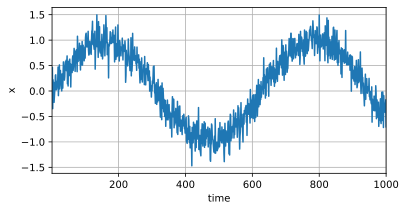

In [2]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2

data = Data()
d2l.plot(data.time, data.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

To begin, we try a model that acts as if the data satisfied a $\tau^{\textrm{th}}$-order Markov condition, and thus predicts $x_t$ using only the past $\tau$ observations. Thus for each time step we have an example with label $y  = x_t$ and features $\mathbf{x}_t = [x_{t-\tau}, \ldots, x_{t-1}]$. The astute reader might have noticed that this results in $1000-\tau$ examples, since we lack sufficient history for $y_1, \ldots, y_\tau$. While we could pad the first $\tau$ sequences with zeros, to keep things simple, we drop them for now. The resulting dataset contains $T - \tau$ examples, where each input to the model has sequence length $\tau$. We create a data iterator on the first 600 examples, covering a period of the sin function.

In [3]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i: i+self.T-self.tau] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

In this example our model will be a standard linear regression.

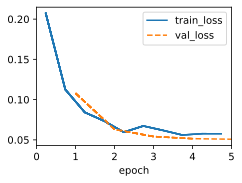

In [4]:
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

### 9.1.4. Prediction

To evaluate our model, we first check how well it performs at one-step-ahead prediction.

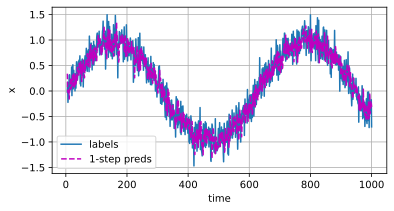

In [5]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

These predictions look good, even near the end at $t=1000$.

But what if we only observed sequence data up until time step 604 (`n_train + tau`) and wished to make predictions several steps into the future? Unfortunately, we cannot directly compute the one-step-ahead prediction for time step 609, because we do not know the corresponding inputs, having seen only up to $x_{604}$. We can address this problem by plugging in our earlier predictions as inputs to our model for making subsequent predictions, projecting forward, one step at a time, until reaching the desired time step:

$$\begin{aligned}
\hat{x}_{605} &= f(x_{601}, x_{602}, x_{603}, x_{604}), \\
\hat{x}_{606} &= f(x_{602}, x_{603}, x_{604}, \hat{x}_{605}), \\
\hat{x}_{607} &= f(x_{603}, x_{604}, \hat{x}_{605}, \hat{x}_{606}),\\
\hat{x}_{608} &= f(x_{604}, \hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}),\\
\hat{x}_{609} &= f(\hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}, \hat{x}_{608}),\\
&\vdots\end{aligned} \tag{9.1.6}$$

Generally, for an observed sequence $x_1, \ldots, x_t$, its predicted output $\hat{x}_{t+k}$ at time step $t+k$ is called the $k$*-step-ahead prediction*. Since we have observed up to $x_{604}$, its $k$-step-ahead prediction is $\hat{x}_{604+k}$. In other words, we will have to keep on using our own predictions to make multistep-ahead predictions. Let's see how well this goes.

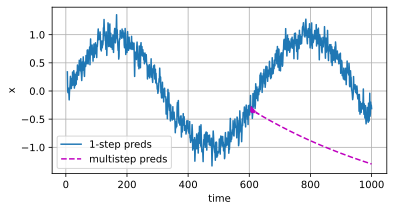

In [7]:
multistep_preds = torch.zeros(data.T)
multistep_preds[:] = data.x
for i in range(data.num_train + data.tau, data.T):
    multistep_preds[i] = model(
        multistep_preds[i-data.tau:i].reshape((1, -1)))
multistep_preds = multistep_preds.detach().numpy()

d2l.plot([data.time[data.tau:], data.time[data.num_train+data.tau:]],
         [onestep_preds, multistep_preds[data.num_train+data.tau:]],
         'time', 'x', legend=['1-step preds', 'multistep preds'], figsize=(6, 3))

Unfortunately, in this case we fail spectacularly. The predictions decay to a constant pretty quickly after a few steps. Why did the algorithm perform so much worse when predicting further into the future? Ultimately, this is down to the fact that errors build up. Let's say that after step 1 we have some error $\epsilon_1 = \bar\epsilon$. Now the *input* for step 2 is perturbed by $\epsilon_1$, hence we suffer some error in the order of $\epsilon_2 = \bar\epsilon + c \epsilon_1$ for some constant $c$, and so on. The predictions can diverge rapidly from the true observations. You may already be familiar with this common phenomenon. For instance, weather forecasts for the next 24 hours tend to be pretty accurate but beyond that, accuracy declines rapidly. We will discuss methods for improving this throughout this chapter and beyond.

Let's take a closer look at the difficulties in $k$-step-ahead predictions by computing predictions on the entire sequence for $k = 1, 4, 16, 64$.

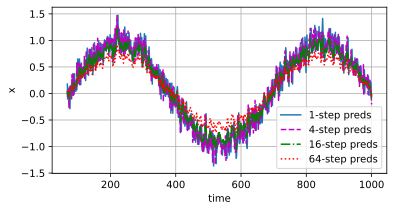

In [ ]:
def k_step_pred(k):
    features = []
    for i in range(data.tau):
        features.append(data.x[i: i+data.T-data.tau-(k-1)])
    # The (i+tau)-th element stores the (i+1)-step-ahead predictions
    for i in range(k):
        preds = model(torch.stack(features[i: i+data.tau], 1))
        features.append(preds.reshape(-1))
    return features[data.tau:]

steps = (1, 4, 16, 64)
preds = k_step_pred(steps[-1])
d2l.plot(data.time[data.tau+steps[-1]-1:],
         [preds[k-1].detach().numpy() for k in steps], 'time', 'x',
         legend=[f'{k}-step preds' for k in steps], figsize=(6, 3))

This clearly illustrates how the quality of the prediction changes as we try to predict further into the future. While the 4-step-ahead predictions still look good, anything beyond that is almost useless.

### 9.1.5. Summary

There is quite a difference in difficulty between interpolation and extrapolation. Consequently, if you have a sequence, always respect the temporal order of the data when training, i.e., never train on future data. Given this kind of data, sequence models require specialized statistical tools for estimation. Two popular choices are autoregressive models and latent-variable autoregressive models. For causal models (e.g., time going forward), estimating the forward direction is typically a lot easier than the reverse direction. For an observed sequence up to time step $t$, its predicted output at time step $t+k$ is the $k$*-step-ahead prediction*. As we predict further in time by increasing $k$, the errors accumulate and the quality of the prediction degrades, often dramatically.

### 9.1.6. Exercises

1. Improve the model in the experiment of this section.
  - Incorporate more than the past four observations? How many do you really need?
  - How many past observations would you need if there was no noise? Hint: you can write $\sin$ and $\cos$ as a differential equation.
  - Can you incorporate older observations while keeping the total number of features constant? Does this improve accuracy? Why?
  - Change the neural network architecture and evaluate the performance. You may train the new model with more epochs. What do you observe?

1. An investor wants to find a good security to buy. They look at past returns to decide which one is likely to do well. What could possibly go wrong with this strategy?

1. Does causality also apply to text? To which extent?

1. Give an example for when a latent autoregressive model might be needed to capture the dynamic of the data.

## 9.2. Converting Raw Text into Sequence Data

Throughout this book, we will often work with text data represented as sequences of words, characters, or word pieces. To get going, we will need some basic tools for converting raw text into sequences of the appropriate form. Typical preprocessing pipelines execute the following steps:

1. Load text as strings into memory.

2. Split the strings into tokens (e.g., words or characters).

3. Build a vocabulary dictionary to associate each vocabulary element with a numerical index.

4. Convert the text into sequences of numerical indices.

In [8]:
import collections
import re
from d2l import torch as d2l

### 9.2.1. Reading the Dataset

Here, we will work with H. G. Wells' [The Time Machine](http://www.gutenberg.org/ebooks/35), a book containing just over 30,000 words. While real applications will typically involve significantly larger datasets, this is sufficient to demonstrate the preprocessing pipeline. The following `_download` method reads the raw text into a string.

In [9]:
class TimeMachine(d2l.DataModule):
    """The Time Machine dataset."""
    def _download(self):
        fname = d2l.download(d2l.DATA_URL + 'timemachine.txt', self.root,
                             '090b5e7e70c295757f55df93cb0a180b9691891a')
        with open(fname) as f:
            return f.read()

data = TimeMachine()
raw_text = data._download()
print(f"len(raw_text): {len(raw_text)}")
raw_text[:60]

len(raw_text): 178979


'The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra'

For simplicity, we ignore punctuation and capitalization when preprocessing the raw text.

In [10]:
@d2l.add_to_class(TimeMachine)
def _preprocess(self, text):
    return re.sub('[^A-Za-z]+', ' ', text).lower()

text = data._preprocess(raw_text)
print(f"len(text): {len(text)}")
text[:60]

len(text): 173428


'the time machine by h g wells i the time traveller for so it'

### 9.2.2. Tokenization

**Tokens** are the atomic (indivisible) units of text. *Each time step corresponds to 1 token*, but what precisely constitutes a token is a design choice. For example, we could represent the sentence "Baby needs a new pair of shoes" as a sequence of 7 words, where the set of all words comprise a large vocabulary (typically tens or hundreds of thousands of words). Or we would represent the same sentence as a much longer sequence of 30 characters, using a much smaller vocabulary (there are only 256 distinct ASCII characters). Below, we tokenize our preprocessed text into a sequence of characters.

In [11]:
@d2l.add_to_class(TimeMachine)
def _tokenize(self, text):
    return list(text)

tokens = data._tokenize(text)
','.join(tokens[:30])

't,h,e, ,t,i,m,e, ,m,a,c,h,i,n,e, ,b,y, ,h, ,g, ,w,e,l,l,s, '

### 9.2.3. Vocabulary

These tokens are still strings. However, the inputs to our models must ultimately consist of numerical inputs. Next, we introduce a class for constructing **vocabularies**, i.e., *objects that associate each distinct token value with a unique index*. First, we determine the set of unique tokens in our training **corpus**. We then assign a numerical index to each unique token. Rare vocabulary elements are often dropped for convenience. Whenever we encounter a token at training or test time that had not been previously seen or was dropped from the vocabulary, we represent it by a special "&lt;unk&gt;" token, signifying that this is an unknown value.

In [13]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(),
                                  key=lambda x: x[1],
                                  reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):  # Index for the unknown token
        return self.token_to_idx['<unk>']

We now construct a vocabulary for our dataset, converting the sequence of strings into a list of numerical indices. Note that we have not lost any information and can easily convert our dataset back to its original (string) representation.

In [15]:
vocab = Vocab(tokens)
indices = vocab[tokens[:10]]
print('indices:', indices)
print('words:', vocab.to_tokens(indices))

indices: [21, 9, 6, 0, 21, 10, 14, 6, 0, 14]
words: ['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm']


### 9.2.4. Putting It All Together

Using the above classes and methods, we package everything into the following `build` method of the `TimeMachine` class, which returns `corpus`, a list of token indices, and `vocab`, the vocabulary of *The Time Machine* corpus. The modifications we did here are: (i) we tokenize text into characters, not words, to simplify the training in later sections; (ii) `corpus` is a single list, not a list of token lists, since each text line in *The Time Machine* dataset is not necessarily a sentence or paragraph.

In [17]:
@d2l.add_to_class(TimeMachine)
def build(self, raw_text, vocab=None):
    tokens = self._tokenize(self._preprocess(raw_text))
    if vocab is None:
        vocab = Vocab(tokens)
    corpus = [vocab[token] for token in tokens]
    return corpus, vocab

corpus, vocab = data.build(raw_text)
print(f"corpus[:10]: {corpus[:10]}")
len(corpus), len(vocab)

corpus[:10]: [21, 9, 6, 0, 21, 10, 14, 6, 0, 14]


(173428, 28)

### 9.2.5. Exploratory Language Statistics

Using the real corpus and the `Vocab` class defined over words, we can inspect basic statistics concerning word use in our corpus. Below, we construct a vocabulary from words used in *The Time Machine* and print the ten most frequently occurring of them.

In [18]:
words = text.split()
vocab = Vocab(words)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

Note that the ten most frequent words are not all that descriptive. You might even imagine that we might see a very similar list if we had chosen any book at random. Articles like "the" and "a", pronouns like "i" and "my", and prepositions like "of", "to", and "in" occur often because they serve common syntactic roles. Such words that are common but not particularly descriptive are often called **stop words** and, in previous generations of text classifiers based on so-called *bag-of-words* representations, they were most often filtered out. However, they carry meaning and it is not necessary to filter them out when working with modern RNN- and Transformer-based neural models. If you look further down the list, you will notice that word frequency decays quickly. The $10^{\textrm{th}}$ most frequent word is less than $1/5$ as common as the most popular. Word frequency tends to follow a power law distribution (specifically the Zipfian) as we go down the ranks. To get a better idea, we plot the figure of the word frequency.

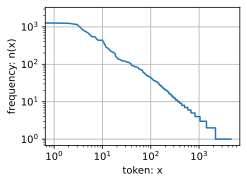

In [19]:
freqs = [freq for token, freq in vocab.token_freqs]
d2l.plot(freqs, xlabel='token: x', ylabel='frequency: n(x)',
         xscale='log', yscale='log')

After dealing with the first few words as exceptions, all the remaining words roughly follow a straight line on a log--log plot. This phenomenon is captured by **Zipf's law**, which states that the frequency $n_i$ of the $i^\textrm{th}$ most frequent word is:

$$n_i \propto \frac{1}{i^\alpha}, \tag{9.2.1} $$

which is equivalent to

$$\log n_i = -\alpha \log i + c, \tag{9.2.2} $$

where $\alpha$ is the exponent that characterizes the distribution and $c$ is a constant. This should already give us pause for thought if we want to model words by counting statistics. After all, we will significantly overestimate the frequency of the tail, also known as the infrequent words. But what about the other word combinations, such as two consecutive words (bigrams), three consecutive words (trigrams), and beyond? Let's see whether the bigram frequency behaves in the same manner as the single word (unigram) frequency.

In [20]:
bigram_tokens = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[('of--the', 309),
 ('in--the', 169),
 ('i--had', 130),
 ('i--was', 112),
 ('and--the', 109),
 ('the--time', 102),
 ('it--was', 99),
 ('to--the', 85),
 ('as--i', 78),
 ('of--a', 73)]

One thing is notable here. Out of the ten most frequent word pairs, nine are composed of both stop words and only one is relevant to the actual book---"the time". Furthermore, let's see whether the trigram frequency behaves in the same manner.

In [21]:
trigram_tokens = ['--'.join(triple) for triple in zip(
    words[:-2], words[1:-1], words[2:])]
trigram_vocab = Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15),
 ('here--and--there', 15),
 ('seemed--to--me', 14),
 ('i--did--not', 14),
 ('i--saw--the', 13),
 ('i--began--to', 13)]

Now, let's visualize the token frequency among these three models: unigrams, bigrams, and trigrams.

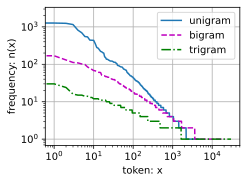

In [22]:
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]
d2l.plot([freqs, bigram_freqs, trigram_freqs], xlabel='token: x',
         ylabel='frequency: n(x)', xscale='log', yscale='log',
         legend=['unigram', 'bigram', 'trigram'])

This figure is quite exciting. First, beyond unigram words, sequences of words also appear to be following Zipf's law, albeit with a smaller exponent $\alpha$ in (9.2.1), depending on the sequence length. Second, the number of distinct $n$-grams is not that large. This gives us hope that there is quite a lot of structure in language. Third, many $n$-grams occur very rarely. This makes certain methods unsuitable for language modeling and motivates the use of deep learning models. We will discuss this in the next section.

---

1、**n-gram 也服从 Zipf 定律，但指数 $\alpha$ 更小**

> “First, beyond unigram words, sequences of words also appear to be following Zipf's law, albeit with a smaller exponent $\alpha$ in (9.2.1), depending on the sequence length.”

- 不仅单个词（unigrams）的频率服从 $ n_i \propto 1/i^\alpha $，**双词**（bigrams）等也大致符合类似的幂律分布。
- 但随着序列长度 $ n $ 增加（如从 unigram → bigram → trigram），**指数 $\alpha$ 变小**。
  - 这意味着：高频 n-gram 和低频 n-gram 之间的**频率差距变小**，分布“更平坦”。
  - 例如：最常见 bigram 的频率可能不像最常见单词那样压倒性地高。
- 尽管如此，整体仍呈现**长尾分布**（long-tailed distribution），这是自然语言的普遍特征。

2、**不同 n-gram 的总数有限，说明语言有强结构**

> “Second, the number of distinct $n$-grams is not that large. This gives us hope that there is quite a lot of structure in language.”

- 虽然理论上 n-gram 的组合数量巨大（比如词汇表大小为 $V$，则 trigram 最多有 $V^3$ 种），但**实际语料中出现的不同 n-gram 数量远小于理论上限**。
- 原因：语言不是随机组合，而是受**语法、语义和习惯用法**约束——即存在**高度结构化**（structure）。
- 这一观察令人鼓舞：说明语言并非“混沌”，而是**可学习、可压缩、可建模**的。

3、**大量 n-gram 极其稀疏，传统方法失效，需深度学习**

> “Third, many $n$-grams occur very rarely. This makes certain methods unsuitable for language modeling and motivates the use of deep learning models.”

- 尽管总种类数有限，但**绝大多数 n-gram 出现次数极少**（甚至只出现一次，即“singleton”）。
- 这导致：
  - **数据稀疏问题**（data sparsity）严重；
  - 传统基于计数的 n-gram 模型（如 Katz backoff、Kneser-Ney smoothing）难以可靠估计这些罕见事件的概率；
  - 模型泛化能力差，尤其在面对新句子或低频组合时。
- 因此，需要更强大的方法——**深度学习模型**（如 RNN、Transformer）能通过**参数共享**、**分布式表示**（word embeddings）和**上下文泛化**来有效处理稀疏性问题。
  - 例如：即使某个 trigram 从未见过，模型仍可通过其组成部分的语义进行合理预测。

**总结**

这段话传达了三个关键洞见：

1. **Zipf 定律具有层级普适性**：不仅适用于单词，也适用于词组，体现语言的统计自相似性；
2. **语言高度结构化**：实际使用的 n-gram 远少于理论可能，说明存在深层规律；
3. **稀疏性挑战传统方法**：促使研究者转向深度学习，以更好地捕捉语言的组合性和泛化能力。

这也为下一节引入神经语言模型（如 RNN、Transformer）做了铺垫——因为它们能**超越局部计数**，**学习语义表示**，从而更鲁棒地处理真实语言中的长尾和稀疏问题。

### 9.2.6. Summary

Text is among the most common forms of sequence data encountered in deep learning. Common choices for what constitutes a token are characters, words, and word pieces. To preprocess text, we usually (i) split text into tokens; (ii) build a vocabulary to map token strings to numerical indices; and (iii) convert text data into token indices for models to manipulate. In practice, the frequency of words tends to follow Zipf's law. This is true not just for individual words (unigrams), but also for $n$-grams.

### 9.2.7. Exercises

1. In the experiment of this section, tokenize text into words and vary the `min_freq` argument value of the `Vocab` instance. Qualitatively characterize how changes in `min_freq` impact the size of the resulting vocabulary.

1. Estimate the exponent of Zipfian distribution for unigrams, bigrams, and trigrams in this corpus.

1. Find some other sources of data (download a standard machine learning dataset, pick another public domain book, scrape a website, etc). For each, tokenize the data at both the word and character levels. How do the vocabulary sizes compare with *The Time Machine* corpus at equivalent values of `min_freq`. Estimate the exponent of the Zipfian distribution corresponding to the unigram and bigram distributions for these corpora. How do they compare with the values that you observed for *The Time Machine* corpus?

## 9.3. Language Models

In Section 9.2, we saw how to map text sequences into tokens, where these tokens can be viewed as a sequence of discrete observations such as words or characters. Assume that the tokens in a text sequence of length $T$ are in turn $x_1, x_2, \ldots, x_T$. The goal of *language models* is to estimate the joint probability of the whole sequence:

$$P(x_1, x_2, \ldots, x_T), \tag{9.3.1} $$

where statistical tools in Section 9.1 can be applied.

In [23]:
import torch
from d2l import torch as d2l

### 9.3.1. Learning Language Models

The obvious question is how we should model a document, or even a sequence of tokens. Suppose that we tokenize text data at the word level. Let's start by applying basic probability rules:

$$P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^T P(x_t  \mid  x_1, \ldots, x_{t-1}). \tag{7.3.2}$$

#### 9.3.1.1. Markov Models and $n$-grams

Among those sequence model analyses in Section 9.1, let's apply Markov models to language modeling. A distribution over sequences satisfies the Markov property of first order if $P(x_{t+1} \mid x_t, \ldots, x_1) = P(x_{t+1} \mid x_t)$. Higher orders correspond to longer dependencies. This leads to a number of approximations that we could apply to model a sequence:

$$ \begin{aligned} P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2) P(x_3) P(x_4),\\ P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_2) P(x_4  \mid  x_3),\\ P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_1, x_2) P(x_4  \mid  x_2, x_3). \end{aligned} \tag{9.3.4}$$

The probability formulae that involve one, two, and three variables are typically referred to as **unigram**, **bigram**, and **trigram** models, respectively. In order to compute the language model, we need to calculate the probability of words and the conditional probability of a word given the previous few words. Note that such probabilities are language model parameters.

#### 9.3.1.2. Word Frequency

Unless we provide some solution to assign such word combinations a nonzero count, we will not be able to use them in a language model. If the dataset is small or if the words are very rare, we might not find even a single one of them.

#### 9.3.1.3. Laplace Smoothing

A common strategy is to perform some form of *Laplace smoothing*. The solution is to add a small constant to all counts. Denote by $n$ the total number of words in the training set and $m$ the number of unique words. This solution helps with singletons, e.g., via

$$\begin{aligned} \hat{P}(x) & = \frac{n(x) + \epsilon_1/m}{n + \epsilon_1}, \\ \hat{P}(x' \mid x) & = \frac{n(x, x') + \epsilon_2 \hat{P}(x')}{n(x) + \epsilon_2}, \\ \hat{P}(x'' \mid x,x') & = \frac{n(x, x',x'') + \epsilon_3 \hat{P}(x'')}{n(x, x') + \epsilon_3}. \end{aligned} \tag{9.3.6}$$

Here $\epsilon_1,\epsilon_2$, and $\epsilon_3$ are hyperparameters. Take $\epsilon_1$ as an example: when $\epsilon_1 = 0$, no smoothing is applied; when $\epsilon_1$ approaches positive infinity, $\hat{P}(x)$ approaches the uniform probability $1/m$. The above is a rather primitive variant of what other techniques can accomplish (Wood et al., 2011).

Unfortunately, models like this get unwieldy rather quickly for the following reasons. First, as discussed in Section 9.2.5, many $n$-grams occur very rarely, making Laplace smoothing rather unsuitable for language modeling. Second, we need to store all counts. Third, this entirely ignores the meaning of the words. For instance, "cat" and "feline" should occur in related contexts. It is quite difficult to adjust such models to additional contexts, whereas, deep learning based language models are well suited to take this into account. Last, long word sequences are almost certain to be novel, hence a model that simply counts the frequency of previously seen word sequences is bound to perform poorly there. Therefore, we focus on using neural networks for language modeling in the rest of the chapter.

### 9.3.2. Perplexity

Next, let's discuss about how to measure the quality of the language model, which we will then use to evaluate our models in the subsequent sections. One way is to check how surprising the text is. A good language model is able to predict, with high accuracy, the tokens that come next.

...

Information theory comes handy here. We defined entropy, surprisal, and cross-entropy when we introduced the softmax regression (Section 4.1.3). If we want to compress text, we can ask about predicting the next token given the current set of tokens. A better language model should allow us to predict the next token more accurately. Thus, it should allow us to spend fewer bits in compressing the sequence. So we can measure it by the cross-entropy loss averaged over all the $n$ tokens of a sequence:

$$\frac{1}{n} \sum_{t=1}^n -\log P(x_t \mid x_{t-1}, \ldots, x_1), \tag{9.3.7} $$

where $P$ is given by a language model and $x_t$ is the actual token observed at time step $t$ from the sequence. This makes the performance on documents of different lengths comparable. For historical reasons, scientists in natural language processing prefer to use a quantity called **perplexity**. In a nutshell, it is the exponential of (9.3.7):

$$\exp\left(-\frac{1}{n} \sum_{t=1}^n \log P(x_t \mid x_{t-1}, \ldots, x_1)\right). \tag{9.3.8} $$

Perplexity can be best understood as the reciprocal of the geometric mean of the number of real choices that we have when deciding which token to pick next. Let's look at a number of cases:

* In the best case scenario, the model always perfectly estimates the probability of the target token as 1. In this case the perplexity of the model is 1.

* In the worst case scenario, the model always predicts the probability of the target token as 0. In this situation, the perplexity is positive infinity.

* At the baseline, the model predicts a uniform distribution over all the available tokens of the vocabulary. In this case, the perplexity equals the number of unique tokens of the vocabulary. In fact, if we were to store the sequence without any compression, this would be the best we could do for encoding it. Hence, this provides a nontrivial upper bound that any useful model must beat.

### 9.3.3. Partitioning Sequences

We will design language models using neural networks and use perplexity to evaluate how good the model is at predicting the next token given the current set of tokens in text sequences. Before introducing the model, let's assume that it processes a minibatch of sequences with predefined length at a time. Now the question is how to read minibatches of input sequences and target sequences at random.

Suppose that the dataset takes the form of a sequence of $T$ token indices in `corpus`. We will partition it into subsequences, where each subsequence has $n$ tokens (time steps). To iterate over (almost) all the tokens of the entire dataset for each epoch and obtain all possible length-$n$ subsequences, we can introduce randomness. More concretely, at the beginning of each epoch, discard the first $d$ tokens, where $d\in [0,n)$ is uniformly sampled at random. The rest of the sequence is then partitioned into $m=\lfloor (T-d)/n \rfloor$ subsequences. Denote by $\mathbf x_t = [x_t, \ldots, x_{t+n-1}]$ the length-$n$ subsequence starting from token $x_t$ at time step $t$. The resulting $m$ partitioned subsequences are $\mathbf x_d, \mathbf x_{d+n}, \ldots, \mathbf x_{d+n(m-1)}$. Each subsequence will be used as an input sequence into the language model.

For language modeling, the goal is to predict the next token based on the tokens we have seen so far; hence the targets (labels) are the original sequence, shifted by one token. The target sequence for any input sequence $\mathbf x_t$ is $\mathbf x_{t+1}$ with length $n$.

<p align="center">
  <img src="https://d2l.ai/_images/lang-model-data.svg"/>
  <br />
  <em>Fig. 9.3.1</em> Obtaining five pairs of input sequences and target sequences from partitioned length-5 subsequences.
</p>

Fig. 9.3.1 shows an example of obtaining five pairs of input sequences and target sequences with $n=5$ and $d=2$.

In [24]:
@d2l.add_to_class(d2l.TimeMachine)
def __init__(self, batch_size, num_steps, num_train=10000, num_val=5000):
    super(d2l.TimeMachine, self).__init__()
    self.save_hyperparameters()
    corpus, self.vocab = self.build(self._download())
    array = torch.tensor([corpus[i:i+num_steps+1]
                                for i in range(len(corpus)-num_steps)])
    self.X, self.Y = array[:,:-1], array[:,1:]

To train language models, we will randomly sample pairs of input sequences and target sequences in minibatches. The following data loader randomly generates a minibatch from the dataset each time. The argument `batch_size` specifies the number of subsequence examples in each minibatch and `num_steps` is the subsequence length in tokens.

In [25]:
@d2l.add_to_class(d2l.TimeMachine)
def get_dataloader(self, train):
    idx = slice(0, self.num_train) if train else slice(
        self.num_train, self.num_train + self.num_val)
    return self.get_tensorloader([self.X, self.Y], train, idx)

As we can see in the following, a minibatch of target sequences can be obtained by shifting the input sequences by one token.

In [26]:
data = d2l.TimeMachine(batch_size=2, num_steps=10)
for X, Y in data.train_dataloader():
    print('X:', X, '\nY:', Y)
    break

X: tensor([[22, 14,  6, 15, 21,  0, 20,  2, 10,  5],
        [ 0, 10, 20,  0, 16, 15, 13, 26,  0,  2]]) 
Y: tensor([[14,  6, 15, 21,  0, 20,  2, 10,  5,  0],
        [10, 20,  0, 16, 15, 13, 26,  0,  2, 15]])


### 9.3.4. Summary and Discussion

Language models estimate the joint probability of a text sequence. For long sequences, $n$-grams provide a convenient model by truncating the dependence. However, there is a lot of structure but not enough frequency to deal efficiently with infrequent word combinations via Laplace smoothing. Thus, we will focus on neural language modeling in subsequent sections. To train language models, we can randomly sample pairs of input sequences and target sequences in minibatches. After training, we will use perplexity to measure the language model quality.

Language models can be scaled up with increased data size, model size, and amount in training compute. Large language models can perform desired tasks by predicting output text given input text instructions. As we will discuss later (e.g., Section 11.9), at the present moment large language models form the basis of state-of-the-art systems across diverse tasks.

### 9.3.5. Exercises

1. Suppose there are 100,000 words in the training dataset. How much word frequency and multi-word adjacent frequency does a four-gram need to store?

1. How would you model a dialogue?

1. What other methods can you think of for reading long sequence data?

1. Consider our method for discarding a uniformly random number of the first few tokens at the beginning of each epoch.
  - Does it really lead to a perfectly uniform distribution over the sequences on the document?
  - What would you have to do to make things even more uniform?

1. If we want a sequence example to be a complete sentence, what kind of problem does this introduce in minibatch sampling? How can we fix it?

## 9.4. Recurrent Neural Networks

In Section 9.3 we described Markov models and $n$-grams for language modeling, where the conditional probability of token $x_t$ at time step $t$ only depends on the $n-1$ previous tokens. If we want to incorporate the possible effect of tokens earlier than time step $t-(n-1)$ on $x_t$, we need to increase $n$. However, the number of model parameters would also increase *exponentially* with it, as we need to store $|\mathcal{V}|^n$ numbers for a vocabulary set $\mathcal{V}$. Hence, rather than modeling $P(x_t \mid x_{t-1}, \ldots, x_{t-n+1})$ it is preferable to use a latent variable model,

$$P(x_t \mid x_{t-1}, \ldots, x_1) \approx P(x_t \mid h_{t-1}), \tag{9.4.1}$$

where $h_{t-1}$ is a *hidden state*  that stores the sequence information up to time step $t-1$. In general, the hidden state at any time step $t$ could be computed based on both the current input $x_{t}$ and the previous hidden state $h_{t-1}$:

$$h_t = f(x_{t}, h_{t-1}). \tag{9.4.2}$$

For a sufficiently powerful function $f$ in (9.4.2), the latent variable model is not an approximation. After all, $h_t$ may simply store all the data it has observed so far. However, it could potentially make both computation and storage expensive.

Recall that we have discussed hidden layers with hidden units Section 5. It is noteworthy that hidden layers and hidden states refer to two very different concepts. Hidden layers are, as explained, layers that are hidden from view on the path from input to output. Hidden states are technically speaking *inputs* to whatever we do at a given step, and they can only be computed by looking at data at previous time steps.

*Recurrent neural networks* (RNNs) are neural networks with hidden states. Before introducing the RNN model, we first revisit the MLP model introduced in Section 5.1.

In [27]:
import torch

### 9.4.1. Neural Networks without Hidden States

Let's take a look at an MLP with a single hidden layer. Let the hidden layer's activation function be $\phi$. Given a minibatch of examples $\mathbf{X} \in \mathbb{R}^{n \times d}$ with batch size $n$ and $d$ inputs, the hidden layer output $\mathbf{H} \in \mathbb{R}^{n \times h}$ is calculated as

$$\mathbf{H} = \phi(\mathbf{X} \mathbf{W}_{\textrm{xh}} + \mathbf{b}_\textrm{h}). \tag{9.4.3}$$

In (9.4.3), we have the weight parameter $\mathbf{W}_{\textrm{xh}} \in \mathbb{R}^{d \times h}$, the bias parameter $\mathbf{b}_\textrm{h} \in \mathbb{R}^{1 \times h}$, and the number of hidden units $h$, for the hidden layer. So armed, we apply broadcasting (see Section 2.1.4) during the summation. Next, the hidden layer output $\mathbf{H}$ is used as input of the output layer, which is given by

$$\mathbf{O} = \mathbf{H} \mathbf{W}_{\textrm{hq}} + \mathbf{b}_\textrm{q}, \tag{9.4.4}$$

where $\mathbf{O} \in \mathbb{R}^{n \times q}$ is the output variable, $\mathbf{W}_{\textrm{hq}} \in \mathbb{R}^{h \times q}$ is the weight parameter, and $\mathbf{b}_\textrm{q} \in \mathbb{R}^{1 \times q}$ is the bias parameter of the output layer.  If it is a classification problem, we can use $\mathrm{softmax}(\mathbf{O})$ to compute the probability distribution of the output categories.

### 9.4.2. Recurrent Neural Networks with Hidden States

Matters are entirely different when we have hidden states. Let's look at the structure in some more detail.

Assume that we have a minibatch of inputs $\mathbf{X}_t \in \mathbb{R}^{n \times d}$ at time step $t$. In other words, for a minibatch of $n$ sequence examples, each row of $\mathbf{X}_t$ corresponds to one example at time step $t$ from the sequence. Next, denote by $\mathbf{H}_t  \in \mathbb{R}^{n \times h}$ the hidden layer output of time step $t$. Unlike with MLP, here we save the hidden layer output $\mathbf{H}_{t-1}$ from the previous time step and introduce a new weight parameter $\mathbf{W}_{\textrm{hh}} \in \mathbb{R}^{h \times h}$ to describe how to use the hidden layer output of the previous time step in the current time step. Specifically, the calculation of the hidden layer output of the current time step is determined by the input of the current time step together with the hidden layer output of the previous time step:

$$\mathbf{H}_t = \phi(\mathbf{X}_t \mathbf{W}_{\textrm{xh}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hh}}  + \mathbf{b}_\textrm{h}). \tag{9.4.5}$$

Compared with (9.4.3), (9.4.5) adds one more term $\mathbf{H}_{t-1} \mathbf{W}_{\textrm{hh}}$ and thus instantiates (9.4.2). From the relationship between hidden layer outputs $\mathbf{H}_t$ and $\mathbf{H}_{t-1}$ of adjacent time steps, we know that these variables *captured and retained the sequence's historical information up to their current time step*, just like the state or memory of the neural network's current time step. Therefore, such a hidden layer output is called a **hidden state**. Since the hidden state uses the same definition of the previous time step in the current time step, the computation of (9.4.5) is *recurrent*. Hence, as we said, neural networks with hidden states based on recurrent computation are named **recurrent neural networks**. Layers that perform the computation of (9.4.5) in RNNs are called **recurrent layers**.

There are many different ways for constructing RNNs. Those with a hidden state defined by (9.4.5) are very common. For time step $t$, the output of the output layer is similar to the computation in the MLP:

$$\mathbf{O}_t = \mathbf{H}_t \mathbf{W}_{\textrm{hq}} + \mathbf{b}_\textrm{q}. \tag{9.4.6}$$

Parameters of the RNN include the weights $\mathbf{W}_{\textrm{xh}} \in \mathbb{R}^{d \times h}, \mathbf{W}_{\textrm{hh}} \in \mathbb{R}^{h \times h}$, and the bias $\mathbf{b}_\textrm{h} \in \mathbb{R}^{1 \times h}$ of the hidden layer, together with the weights $\mathbf{W}_{\textrm{hq}} \in \mathbb{R}^{h \times q}$ and the bias $\mathbf{b}_\textrm{q} \in \mathbb{R}^{1 \times q}$ of the output layer. *It is worth mentioning that even at different time steps, RNNs always use these model parameters. Therefore, the parametrization cost of an RNN does not grow as the number of time steps increases*.

Fig. 9.4.1 illustrates the computational logic of an RNN at three adjacent time steps. At any time step $t$, the computation of the hidden state can be treated as: (i) concatenating the input $\mathbf{X}_t$ at the current time step $t$ and the hidden state $\mathbf{H}_{t-1}$ at the previous time step $t-1$; (ii) feeding the concatenation result into a fully connected layer with the activation function $\phi$. The output of such a fully connected layer is the hidden state $\mathbf{H}_t$ of the current time step $t$. In this case, the model parameters are the concatenation of $\mathbf{W}_{\textrm{xh}}$ and $\mathbf{W}_{\textrm{hh}}$, and a bias of $\mathbf{b}_\textrm{h}$, all from (9.4.5). The hidden state of the current time step $t$, $\mathbf{H}_t$, will participate in computing the hidden state $\mathbf{H}_{t+1}$ of the next time step $t+1$. What is more, $\mathbf{H}_t$ will also be fed into the fully connected output layer to compute the output $\mathbf{O}_t$ of the current time step $t$.

<p align="center">
  <img src="http://d2l.ai/_images/rnn.svg"/>
  <br />
  <em>Fig. 9.4.1</em> An RNN with a hidden state.
</p>

We just mentioned that the calculation of $\mathbf{X}_t \mathbf{W}_{\textrm{xh}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hh}}$ for the hidden state is equivalent to matrix multiplication of the concatenation of $\mathbf{X}_t$ and $\mathbf{H}_{t-1}$ and the concatenation of $\mathbf{W}_{\textrm{xh}}$ and $\mathbf{W}_{\textrm{hh}}$. Though this can be proven mathematically, in the following we just use a simple code snippet as a demonstration. To begin with, we define matrices `X`, `W_xh`, `H`, and `W_hh`, whose shapes are (3, 1), (1, 4), (3, 4), and (4, 4), respectively. Multiplying `X` by `W_xh`, and `H` by `W_hh`, and then adding these two products, we obtain a matrix of shape (3, 4).

---

这段文字详细解释了**循环神经网络（RNN, Recurrent Neural Network）**的核心机制，特别是**隐藏状态（hidden state）**的定义、作用和计算方式。以下是对这段内容的逐层解读：

一、**基本设定**

- **输入**：在时间步 $ t $，有一个小批量输入矩阵  
  $$\mathbf{X}_t \in \mathbb{R}^{n \times d}$$
  其中：
  - $ n $ 是批次大小（batch size），即同时处理的序列样本数；
  - $ d $ 是每个时间步输入特征的维度。

- **隐藏状态**：  
  $$\mathbf{H}_t \in \mathbb{R}^{n \times h}$$
  表示在时间步 $ t $ 的隐藏层输出（即“隐藏状态”），其中 $ h $ 是隐藏单元的数量。

二、**RNN 的核心公式（关键创新）**

与普通多层感知机（MLP）不同，RNN 在计算当前隐藏状态时**不仅依赖当前输入，还依赖上一时刻的隐藏状态**：

$$\mathbf{H}_t = \phi(\mathbf{X}_t \mathbf{W}_{\textrm{xh}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hh}} + \mathbf{b}_\textrm{h}) \tag{9.4.5}$$

- $ \mathbf{W}_{\textrm{xh}} \in \mathbb{R}^{d \times h} $：输入到隐藏层的权重；
- $ \mathbf{W}_{\textrm{hh}} \in \mathbb{R}^{h \times h} $：**隐藏状态自循环**的权重（这是 RNN 的关键！）；
- $ \mathbf{b}_\textrm{h} \in \mathbb{R}^{1 \times h} $：隐藏层偏置；
- $ \phi $：激活函数（如 $\tanh$ 或 $\text{ReLU}$）。

> ✅ **关键点**：  
> 由于 $ \mathbf{H}_{t-1} $ 被用作当前计算的一部分，**历史信息被逐步传递并累积**，使得网络具备“记忆”能力。

三、**“隐藏状态”的含义**

- 隐藏状态 $ \mathbf{H}_t $ **编码了从序列开始到时间步 $ t $ 的所有相关信息**。
- 它就像一个**动态更新的内部记忆**，在每个时间步根据新输入和旧状态进行更新。
- 正因为这种**递归（recurrent）**的计算方式（当前状态依赖前一状态），这类网络被称为 **Recurrent Neural Network**。

四、**输出层计算**

在每个时间步，还可以生成一个输出（例如用于预测下一个词或分类）：

$$\mathbf{O}_t = \mathbf{H}_t \mathbf{W}_{\textrm{hq}} + \mathbf{b}_\textrm{q} \tag{9.4.6}$$

- $ \mathbf{W}_{\textrm{hq}} \in \mathbb{R}^{h \times q} $：隐藏层到输出层的权重；
- $ \mathbf{b}_\textrm{q} \in \mathbb{R}^{1 \times q} $：输出偏置；
- $ q $ 是输出维度（如词汇表大小）。

> 注意：输出可以只在最后一个时间步使用（如情感分类），也可以在每个时间步都使用（如机器翻译）。

五、**参数共享（Parameter Sharing）**—— RNN 的巨大优势

- 所有时间步**共享同一套参数**：  
  $ \mathbf{W}_{\textrm{xh}}, \mathbf{W}_{\textrm{hh}}, \mathbf{b}_\textrm{h}, \mathbf{W}_{\textrm{hq}}, \mathbf{b}_\textrm{q} $。
- 这意味着：**无论序列多长，模型参数数量不变**。
- 对比：如果不用 RNN，而用 MLP 处理长度为 $ T $ 的序列，就需要 $ T $ 倍的参数！

> ✅ 这使得 RNN 能够处理**任意长度的序列**，且具有良好的泛化能力。

六、**等价视角：拼接输入与前一状态**

公式 (9.4.5) 可以等价地看作：

1. 将当前输入 $ \mathbf{X}_t $ 和前一隐藏状态 $ \mathbf{H}_{t-1} $ **横向拼接**：
   $$[\mathbf{X}_t \; ; \; \mathbf{H}_{t-1}] \in \mathbb{R}^{n \times (d + h)}$$
2. 将权重矩阵也拼接：
   $$\begin{bmatrix} \mathbf{W}_{\textrm{xh}} \\ \mathbf{W}_{\textrm{hh}} \end{bmatrix} \in \mathbb{R}^{(d + h) \times h}$$
3. 然后做一次全连接变换 + 激活函数。

这说明 RNN 的每一步本质上是一个**带记忆的全连接层**。

**总结：RNN 的核心思想**

| 特性 | 说明 |
|------|------|
| **时间依赖** | 当前输出依赖过去状态 |
| **隐藏状态** | 作为“记忆”传递历史信息 |
| **参数共享** | 所有时间步使用相同参数，模型大小与序列长度无关 |
| **递归结构** | 同一计算单元在时间上重复使用 |

> ⚠️ 局限性：虽然 RNN 理论上能记住任意长的历史，但实践中存在**梯度消失/爆炸**问题，难以学习长期依赖。这也是后来 LSTM、GRU 等改进模型出现的原因。

In [28]:
X, W_xh = torch.randn(3, 1), torch.randn(1, 4)
H, W_hh = torch.randn(3, 4), torch.randn(4, 4)
torch.matmul(X, W_xh) + torch.matmul(H, W_hh)

tensor([[ 0.0645, -1.0594, -1.7902,  1.6952],
        [ 1.0334,  0.2218, -0.3802, -0.7546],
        [-0.2836,  0.1615, -0.4365,  0.1757]])

Now we concatenate the matrices `X` and `H` along columns (axis 1), and the matrices `W_xh` and `W_hh` along rows (axis 0). These two concatenations result in matrices of shape (3, 5) and of shape (5, 4), respectively. Multiplying these two concatenated matrices, we obtain the same output matrix of shape (3, 4) as above.

In [ ]:
torch.matmul(torch.cat((X, H), 1), torch.cat((W_xh, W_hh), 0))

tensor([[ 0.0645, -1.0594, -1.7902,  1.6952],
        [ 1.0334,  0.2218, -0.3802, -0.7546],
        [-0.2836,  0.1615, -0.4365,  0.1757]])

### 9.4.3. RNN-Based Character-Level Language Models

Recall that for language modeling in Section 9.3, we aim to predict the next token based on the current and past tokens; thus we shift the original sequence by one token as the targets (labels). Bengio et al. (2003) first proposed to use a neural network for language modeling. In the following we illustrate how RNNs can be used to build a language model. Let the minibatch size be one, and the sequence of the text be "machine". To simplify training in subsequent sections, we tokenize text into characters rather than words and consider a *character-level language model*. Fig. 9.4.2 demonstrates how to predict the next character based on the current and previous characters via an RNN for character-level language modeling.

<p align="center">
  <img src="https://d2l.ai/_images/rnn-train.svg"/>
  <br />
  <em>Fig. 9.4.2</em> A character-level language model based on the RNN. The input and target sequences are “machin” and “achine”, respectively.
</p>

During the training process, we run a softmax operation on the output from the output layer for each time step, and then use the cross-entropy loss to compute the error between the model output and the target. Because of the recurrent computation of the hidden state in the hidden layer, the output, $\mathbf{O}_3$,  of time step 3 in Fig. 9.4.2 is determined by the text sequence "m", "a", and "c". Since the next character of the sequence in the training data is "h", the loss of time step 3 will depend on the probability distribution of the next character generated based on the feature sequence "m", "a", "c" and the target "h" of this time step.

In practice, each token is represented by a $d$-dimensional vector, and we use a batch size $n>1$. Therefore, the input $\mathbf X_t$ at time step $t$ will be an $n\times d$ matrix, which is identical to what we discussed in Section 9.4.2.

### 9.4.4. Summary

A neural network that uses recurrent computation for hidden states is called a recurrent neural network (RNN). The hidden state of an RNN can capture historical information of the sequence up to the current time step. With recurrent computation, the number of RNN model parameters does not grow as the number of time steps increases. As for applications, an RNN can be used to create character-level language models.

### 9.4.5. Exercises

1. If we use an RNN to predict the next character in a text sequence, what is the required dimension for any output?

1. Why can RNNs express the conditional probability of a token at some time step based on all the previous tokens in the text sequence?

1. What happens to the gradient if you backpropagate through a long sequence?

1. What are some of the problems associated with the language model described in this section?

## 9.5. Recurrent Neural Network Implementation from Scratch

In [12]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 9.5.1. RNN Model

We begin by defining a class to implement the RNN model (Section 9.4.2). Note that the number of hidden units `num_hiddens` is a tunable hyperparameter.

In [13]:
class RNNScratch(d2l.Module):
    """The RNN model implemented from scratch."""
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W_xh = nn.Parameter(
            torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(
            torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

The `forward` method below defines how to compute the output and hidden state at any time step, given the current input and the state of the model at the previous time step. Note that the RNN model loops through the outermost dimension of `inputs`, updating the hidden state one time step at a time. The model here uses a $\tanh$ activation function (Section 5.1.2.3).

In [14]:
@d2l.add_to_class(RNNScratch)
def forward(self, inputs, state=None):
    if state is None:
        # Initial state with shape: (batch_size, num_hiddens)
        state = torch.zeros((inputs.shape[1],
                             self.num_hiddens),
                             device=inputs.device)
    else:
        state, = state
    outputs = []
    for X in inputs:  # Shape of inputs: (num_steps, batch_size, num_inputs)
        state = torch.tanh(torch.matmul(X, self.W_xh)
                           + torch.matmul(state, self.W_hh)
                           + self.b_h)
        outputs.append(state)
    return outputs, state

---
牧之：
- 这里定义的是循环层，稍后会作为输出层的输入。循环层有各种其他变体，例如 LSTM 和 GRU，也可以进一步堆叠，形成深度 RNN。
- 需要记一下循环层输入输出的形状，稍后会经常用到：
  - 输入的形状：`(num_steps, batch_size, num_inputs)`。所以，这里代码用 `inputs.shape[1]` 来表示 `batch_size`。
    - 不过，需要注意，原始输入的形状是 `(batch_size, num_steps)`，在循环层之前，还有一个嵌入层，当前是用 One-Hot 编码来实现的，在嵌入层，原始输入被转置后再使用，形状就变成 `(num_steps, batch_size, num_inputs)` 了。将 `num_steps` 置于最外层，是为了在循环层内部处理时方便。
  - 输出的形状：一个长度为 `num_steps` 的 List，其每个元素的形状为 `(batch_size, num_hiddens)`。
- 返回的隐状态 state 是最后一个时间步的隐藏层输出，所以形状是 `(batch_size, num_hiddens)`。

We can feed a minibatch of input sequences into an RNN model as follows.

In [15]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNNScratch(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)

Let’s check whether the RNN model produces results of the correct shapes to ensure that the dimensionality of the hidden state remains unchanged.

In [16]:
def check_len(a, n):
    """Check the length of a list."""
    assert len(a) == n, f'list\'s length {len(a)} != expected length {n}'

def check_shape(a, shape):
    """Check the shape of a tensor."""
    assert a.shape == shape, \
            f'tensor\'s shape {a.shape} != expected shape {shape}'

check_len(outputs, num_steps)
check_shape(outputs[0], (batch_size, num_hiddens))
check_shape(state, (batch_size, num_hiddens))

### 9.5.2. RNN-Based Language Model

The following `RNNLMScratch` class defines an RNN-based language model, where we pass in our RNN via the `rnn` argument of the `__init__` method. When training language models, the inputs and outputs are from the same vocabulary. Hence, they have the same dimension, which is equal to the vocabulary size. Note that we use perplexity to evaluate the model. As discussed in Section 9.3.2, this ensures that sequences of different length are comparable.

In [17]:
class RNNLMScratch(d2l.Classifier):
    """The RNN-based language model implemented from scratch."""
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.init_params()

    def init_params(self):
        self.W_hq = nn.Parameter(
            torch.randn(self.rnn.num_hiddens, self.vocab_size) * self.rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=True)
        return l

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=False)

#### 9.5.2.1. One-Hot Encoding

When dealing with such categorical data, the most common strategy is to represent each item by a *one-hot encoding* (recall from Section 4.1.1). A one-hot encoding is a vector whose length is given by the size of the vocabulary $N$, where all entries are set to $0$, except for the entry corresponding to our token, which is set to $1$. For example, if the vocabulary had five elements, then the one-hot vectors corresponding to indices 0 and 2 would be the following.

In [18]:
F.one_hot(torch.tensor([0, 2]), 5)

tensor([[1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0]])

The minibatches that we sample at each iteration will take the shape (*batch size, number of time steps*). Once representing each input as a one-hot vector, we can think of each minibatch as a three-dimensional tensor, where the length along the third axis is given by the vocabulary size (`len(vocab)`). We often transpose the input so that we will obtain an output of shape (number of time steps, batch size, vocabulary size). This will allow us to loop more conveniently through the outermost dimension for updating hidden states of a minibatch, time step by time step (e.g., in the above `forward` method).

In [19]:
@d2l.add_to_class(RNNLMScratch)
def one_hot(self, X):
    # Output shape: (num_steps, batch_size, vocab_size)
    return F.one_hot(X.T, self.vocab_size).type(torch.float32)

#### 9.5.2.2. Transforming RNN Outputs

The language model uses a fully connected output layer to transform RNN outputs into token predictions at each time step.

In [20]:
@d2l.add_to_class(RNNLMScratch)
def output_layer(self, rnn_outputs):
    outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
    return torch.stack(outputs, 1)

@d2l.add_to_class(RNNLMScratch)
def forward(self, X, state=None):
    embs = self.one_hot(X)
    rnn_outputs, _ = self.rnn(embs, state)
    return self.output_layer(rnn_outputs)

---
牧之：
- 这里通过将 Recurrent Layer 连接一个 Output Layer，组成了一个 RNN。
- Output Layer 在前向传播时，需要将隐状态形状转换成输出形状，实现的方式挺巧妙：
  - Recurrent Layer 输出的形状：一个长度为 `num_steps` 的 List，其每个元素的形状为 `(batch_size, num_hiddens)`。
  - 先通过列表生成式按 `num_steps` 分别计算输出值，此时 `outputs` 也是一个长度为 `num_steps` 的 List，其每个元素的形状为 `(batch_size, num_outputs)`。
  - 然后将这个 List 在第二个维堆叠，即将 List 的长度 `num_steps` 插入到第二个维度，`outputs` 变为 `(batch_size, num_steps, num_outputs)` 。

Let’s check whether the forward computation produces outputs with the correct shape.

In [21]:
model = RNNLMScratch(rnn, num_inputs)
outputs = model(torch.ones((batch_size, num_steps), dtype=torch.int64))
check_shape(outputs, (batch_size, num_steps, num_inputs))

### 9.5.3. Gradient Clipping

While you are already used to thinking of neural networks as "deep" in the sense that many layers separate the input and output even within a single time step, the length of the sequence introduces a new notion of depth. In addition to the passing through the network in the input-to-output direction, inputs at the first time step must pass through a chain of $T$ layers along the time steps in order to influence the output of the model at the final time step. Taking the backwards view, in each iteration, we backpropagate gradients through time, resulting in a chain of matrix-products of length  $\mathcal{O}(T)$. As mentioned in Section 5.4, this can result in numerical instability, causing the gradients either to explode or vanish, depending on the properties of the weight matrices.

Dealing with vanishing and exploding gradients is a fundamental problem when designing RNNs and has inspired some of the biggest advances in modern neural network architectures. In the next chapter, we will talk about specialized architectures that were designed in hopes of mitigating the vanishing gradient problem. However, even modern RNNs often suffer from exploding gradients. One inelegant but ubiquitous solution is to simply clip the gradients forcing the resulting "clipped" gradients to take smaller values.

Generally speaking, when optimizing some objective by gradient descent, we iteratively update the parameter of interest, say a vector $\mathbf{x}$, but pushing it in the direction of the negative gradient $\mathbf{g}$ (in stochastic gradient descent, we calculate this gradient on a randomly sampled minibatch). For example, with learning rate $\eta > 0$, each update takes the form $\mathbf{x} \gets \mathbf{x} - \eta \mathbf{g}$. Let's further assume that the objective function $f$ is sufficiently smooth. Formally, we say that the objective is **Lipschitz continuous** with constant $L$, meaning that for any $\mathbf{x}$ and $\mathbf{y}$, we have

$$|f(\mathbf{x}) - f(\mathbf{y})| \leq L \|\mathbf{x} - \mathbf{y}\|. \tag{9.5.1}$$

As you can see, when we update the parameter vector by subtracting $\eta \mathbf{g}$, the change in the value of the objective depends on the learning rate, the norm of the gradient and $L$ as follows:

$$|f(\mathbf{x}) - f(\mathbf{x} - \eta\mathbf{g})| \leq L \eta\|\mathbf{g}\|.\tag{9.5.2}$$

In other words, the objective cannot change by more than $L \eta \|\mathbf{g}\|$. Having a small value for this upper bound might be viewed as good or bad. On the downside, we are limiting the speed at which we can reduce the value of the objective. On the bright side, this limits by just how much we can go wrong in any one gradient step.

When we say that gradients explode, we mean that $\|\mathbf{g}\|$ becomes excessively large. In this worst case, we might do so much damage in a single gradient step that we could undo all of the progress made over the course of thousands of training iterations. When gradients can be so large, neural network training often diverges, failing to reduce the value of the objective. At other times, training eventually converges but is unstable owing to massive spikes in the loss.

One way to limit the size of $L \eta \|\mathbf{g}\|$ is to shrink the learning rate $\eta$ to tiny values. This has the advantage that we do not bias the updates. But what if we only *rarely* get large gradients? This drastic move slows down our progress at all steps, just to deal with the rare exploding gradient events. A popular alternative is to adopt a *gradient clipping* heuristic projecting the gradients $\mathbf{g}$ onto a ball of some given radius $\theta$ as follows:

$$\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right) \mathbf{g}. \tag{9.5.3}$$

This ensures that the gradient norm never exceeds $\theta$ and that the updated gradient is entirely aligned with the original direction of $\mathbf{g}$. It also has the desirable side-effect of limiting the influence any given minibatch (and within it any given sample) can exert on the parameter vector. This bestows a certain degree of robustness to the model. To be clear, it is a hack. Gradient clipping means that we are not always following the true gradient and it is hard to reason analytically about the possible side effects. However, it is a very useful hack, and is widely adopted in RNN implementations in most deep learning frameworks.

Below we define a method to clip gradients, which is invoked by the `fit_epoch` method of the `d2l.Trainer` class (see Section 3.4). Note that when computing the gradient norm, we are concatenating all model parameters, treating them as a single giant parameter vector.

---

牧之：L-Lipschitz 连续 这个假设苛刻吗？现实中容易满足吗？

In [22]:
@d2l.add_to_class(d2l.Trainer)
def clip_gradients(self, grad_clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > grad_clip_val:
        for param in params:
            param.grad[:] *= grad_clip_val / norm

### 9.5.4. Training

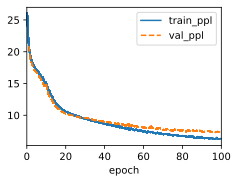

In [23]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNNScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLMScratch(rnn, vocab_size=len(data.vocab), lr=1)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

### 9.5.5. Decoding

The following `predict` method generates a continuation, one character at a time, after ingesting a user-provided `prefix`. When looping through the characters in `prefix`, we keep passing the hidden state to the next time step but do not generate any output. This is called the **warm-up** period. After ingesting the prefix, we are now ready to begin emitting the subsequent characters, each of which will be fed back into the model as the input at the next time step.

In [24]:
@d2l.add_to_class(RNNLMScratch)
def predict(self, prefix, num_preds, vocab, device=None):
    state, outputs = None, [vocab[prefix[0]]]
    for i in range(len(prefix) + num_preds - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        embs = self.one_hot(X)
        rnn_outputs, state = self.rnn(embs, state)
        if i < len(prefix) - 1:  # Warm-up period
            outputs.append(vocab[prefix[i + 1]])
        else:  # Predict num_preds steps
            Y = self.output_layer(rnn_outputs)
            outputs.append(int(Y.argmax(axis=2).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

---
牧之：
- 要在 for 循环 -1 是因为进行 `len(prefix)` 预热后，已经可以输出一个预测 token 了，所以也可以看到，真正的预热期是 `len(prefix) - 1`。
- 预热阶段是为了捕捉隐藏状态，不用预热阶段的模型输出，而是直接用 prefix 的值。
- 输入是 2 维的，`(num_steps, batch_size)`。输出是 3 维的，`(batch_size, num_steps, num_outputs)`，所以用 `Y.argmax(axis=2).reshape(1)` 选出 `num_outputs` 维度上最大值的序号，其实就是 token，并用 `reshape(1)` 去除多余维度。

In the following, we specify the prefix and have it generate 20 additional characters.

In [25]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has our the time time t'

### 9.5.6. Summary

We can train RNN-based language models to generate text following the user-provided text prefix. A simple RNN language model consists of input encoding, RNN modeling, and output generation. During training, gradient clipping can mitigate the problem of exploding gradients but does not address the problem of vanishing gradients. In the experiment, we implemented a simple RNN language model and trained it with gradient clipping on sequences of text, tokenized at the character level. By conditioning on a prefix, we can use a language model to generate likely continuations, which proves useful in many applications, e.g., autocomplete features.

### 9.5.7. Exercises

1. Does the implemented language model predict the next token based on all the past tokens up to the very first token in *The Time Machine*?

1. Which hyperparameter controls the length of history used for prediction?

1. Show that one-hot encoding is equivalent to picking a different embedding for each object.

1. Adjust the hyperparameters (e.g., number of epochs, number of hidden units, number of time steps in a minibatch, and learning rate) to improve the perplexity. How low can you go while sticking with this simple architecture?

1. Replace one-hot encoding with learnable embeddings. Does this lead to better performance?

1. Conduct an experiment to determine how well this language model trained on *The Time Machine* works on other books by H. G. Wells, e.g., *The War of the Worlds*.

1. Conduct another experiment to evaluate the perplexity of this model on books written by other authors.

1. Modify the prediction method so as to use sampling rather than picking the most likely next character.
  * What happens?
  * Bias the model towards more likely outputs, e.g., by sampling from $q(x_t \mid x_{t-1}, \ldots, x_1) \propto P(x_t \mid x_{t-1}, \ldots, x_1)^\alpha$ for $\alpha > 1$.

1. Run the code in this section without clipping the gradient. What happens?

1. Replace the activation function used in this section with ReLU
   and repeat the experiments in this section. Do we still need gradient clipping? Why?

## 9.6. Concise Implementation of Recurrent Neural Networks

In [27]:
from torch import nn
from d2l import torch as d2l

### 9.6.1. Defining the Model

We define the following class using the RNN implemented by high-level APIs.

In [26]:
class RNN(d2l.Module):
    """The RNN model implemented with high-level APIs."""
    def __init__(self, num_inputs, num_hiddens):
        super().__init__()
        self.save_hyperparameters()
        self.rnn = nn.RNN(num_inputs, num_hiddens)

    def forward(self, inputs, H=None):
        return self.rnn(inputs, H)

Inheriting from the `RNNLMScratch` class in Section 9.5, the following `RNNLM` class defines a complete RNN-based language model. Note that we need to create a separate fully connected output layer.

In [28]:
class RNNLM(d2l.RNNLMScratch):
    """The RNN-based language model implemented with high-level APIs."""
    def init_params(self):
        self.linear = nn.LazyLinear(self.vocab_size)

    def output_layer(self, hiddens):
        return self.linear(hiddens).swapaxes(0, 1)

### 9.6.2. Training and Predicting

In [29]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNN(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
model.predict('it has', 20, data.vocab)

/home/lancer/miniforge3/envs/d2l/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


'it haswmmmmmmmmmmmmmmmmmmm'

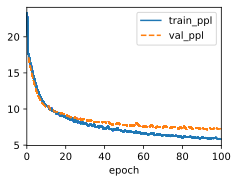

In [30]:
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [ ]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has is the time trave t'

### 9.6.3. Summary

High-level APIs in deep learning frameworks provide implementations of standard RNNs. These libraries help you to avoid wasting time reimplementing standard models. Moreover, framework implementations are often highly optimized, leading to significant (computational) performance gains when compared with implementations from scratch.

### 9.6.4. Exercises

1. Can you make the RNN model overfit using the high-level APIs?

1. Implement the autoregressive model of Section 9.1 using an RNN.

## 9.7. Backpropagation Through Time

Applying backpropagation in RNNs is called *backpropagation through time* (Werbos, 1990). This procedure requires us to expand (or unroll) the computational graph of an RNN one time step at a time. The unrolled RNN is essentially a feedforward neural network with the special property that the same parameters are repeated throughout the unrolled network, appearing at each time step.

...

Complications arise because sequences can be rather long. It is not unusual to work with text sequences consisting of over a thousand tokens. Note that this poses problems both from a computational (too much memory) and optimization (numerical instability) standpoint. Input from the first step passes through over 1000 matrix products before arriving at the output, and another 1000 matrix products are required to compute the gradient. We now analyze what can go wrong and how to address it in practice.

### 9.7.1. Analysis of Gradients in RNNs

Thus, per (9.7.5), we can remove the recurrent computation in (9.7.4) with

$$\frac{\partial h_t}{\partial w_\textrm{h}}=\frac{\partial f(x_{t},h_{t-1},w_\textrm{h})}{\partial w_\textrm{h}}+\sum_{i=1}^{t-1}\left(\prod_{j=i+1}^{t} \frac{\partial f(x_{j},h_{j-1},w_\textrm{h})}{\partial h_{j-1}} \right) \frac{\partial f(x_{i},h_{i-1},w_\textrm{h})}{\partial w_\textrm{h}}. \tag{9.7.7}$$

While we can use the chain rule to compute $\partial h_t/\partial w_\textrm{h}$ recursively, this chain can get very long whenever $t$ is large. Let's discuss a number of strategies for dealing with this problem.

#### 9.7.1.1. Full Computation

#### 9.7.1.2. Truncating Time Steps

Alternatively, we can truncate the sum in (9.7.7) after $\tau$ steps. This is what we have been discussing so far. This leads to an *approximation* of the true gradient, simply by terminating the sum at $\partial h_{t-\tau}/\partial w_\textrm{h}$. In practice this works quite well. It is what is commonly referred to as truncated backpropgation through time (Jaeger, 2002). One of the consequences of this is that the model focuses primarily on short-term influence rather than long-term consequences. This is actually *desirable*, since it biases the estimate towards simpler and more stable models.

#### 9.7.1.3. Randomized Truncation

Last, we can replace $\partial h_t/\partial w_\textrm{h}$ by a random variable which is correct in expectation but truncates the sequence. This is achieved by using a sequence of $\xi_t$ with predefined $0 \leq \pi_t \leq 1$, where $P(\xi_t = 0) = 1-\pi_t$ and $P(\xi_t = \pi_t^{-1}) = \pi_t$, thus $E[\xi_t] = 1$. We use this to replace the gradient $\partial h_t/\partial w_\textrm{h}$ in (9.7.4) with

$$z_t= \frac{\partial f(x_{t},h_{t-1},w_\textrm{h})}{\partial w_\textrm{h}} +\xi_t \frac{\partial f(x_{t},h_{t-1},w_\textrm{h})}{\partial h_{t-1}} \frac{\partial h_{t-1}}{\partial w_\textrm{h}}. \tag{9.7.8}$$

It follows from the definition of $\xi_t$ that $E[z_t] = \partial h_t/\partial w_\textrm{h}$. Whenever $\xi_t = 0$ the recurrent computation terminates at that time step $t$. This leads to a weighted sum of sequences of varying lengths, where long sequences are rare but appropriately overweighted. This idea was proposed by Tallec and Ollivier (2017).

#### 9.7.1.4. Comparing Strategies

Unfortunately, while appealing in theory, randomized truncation does not work much better than regular truncation, most likely due to a number of factors. First, the effect of an observation after a number of backpropagation steps into the past is quite sufficient to capture dependencies in practice. Second, the increased variance counteracts the fact that the gradient is more accurate with more steps. Third, we actually *want* models that have only a short range of interactions. Hence, regularly truncated backpropagation through time has a slight regularizing effect that can be desirable.

### 9.7.2. Backpropagation Through Time in Detail

### 9.7.3. Summary

Backpropagation through time is merely an application of backpropagation to sequence models with a hidden state. Truncation, such as regular or randomized, is needed for computational convenience and numerical stability. High powers of matrices can lead to divergent or vanishing eigenvalues. This manifests itself in the form of exploding or vanishing gradients. For efficient computation, intermediate values are cached during backpropagation through time.

### 9.7.4. Exercises

1. Assume that we have a symmetric matrix $\mathbf{M} \in \mathbb{R}^{n \times n}$ with eigenvalues $\lambda_i$ whose corresponding eigenvectors are $\mathbf{v}_i$ ($i = 1, \ldots, n$). Without loss of generality, assume that they are ordered in the order $|\lambda_i| \geq |\lambda_{i+1}|$.
   - Show that $\mathbf{M}^k$ has eigenvalues $\lambda_i^k$.
   - Prove that for a random vector $\mathbf{x} \in \mathbb{R}^n$, with high probability $\mathbf{M}^k \mathbf{x}$ will be very much aligned with the eigenvector $\mathbf{v}_1$ of $\mathbf{M}$. Formalize this statement.
   - What does the above result mean for gradients in RNNs?

1. Besides gradient clipping, can you think of any other methods to cope with gradient explosion in recurrent neural networks?